Mounted at /content/drive
Available Excel files:
1: T1-Load.xlsx
2: T2-Load.xlsx
3: T1- No Load.xlsx
4: T2-No Load.xlsx
5: T3_No load.xlsx
6: T3-Load.xlsx
7: exT3-Load.xlsx
8: Predicted(T2-Load).xlsx
9: Predicted(T3-Load).xlsx
10: Predicted(T1- No Load).xlsx
11: Predicted(T2-No Load).xlsx
12: Predicted(T3_No load).xlsx
13: Predicted(T1-Load).xlsx
Select a file by number: 1
You selected: T1-Load.xlsx


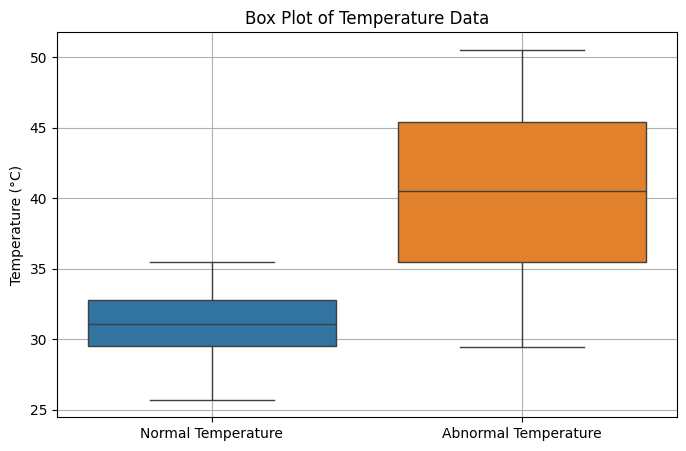

Random Forest Accuracy: 99.98%
Predictions saved successfully at: /content/drive/My Drive/dataset/Predicted(T1-Load).xlsx


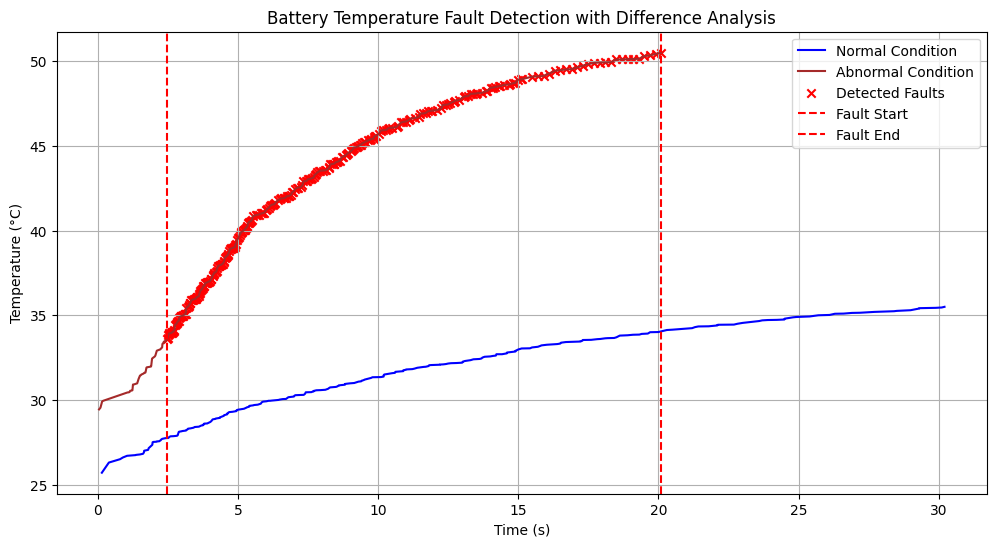

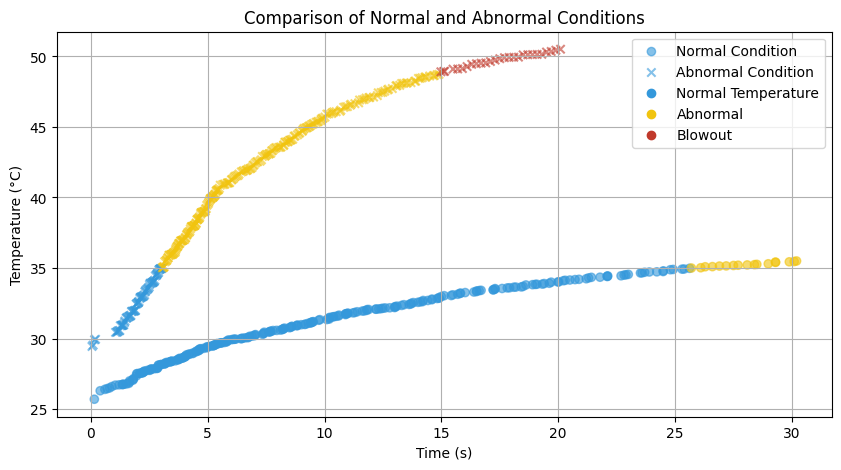

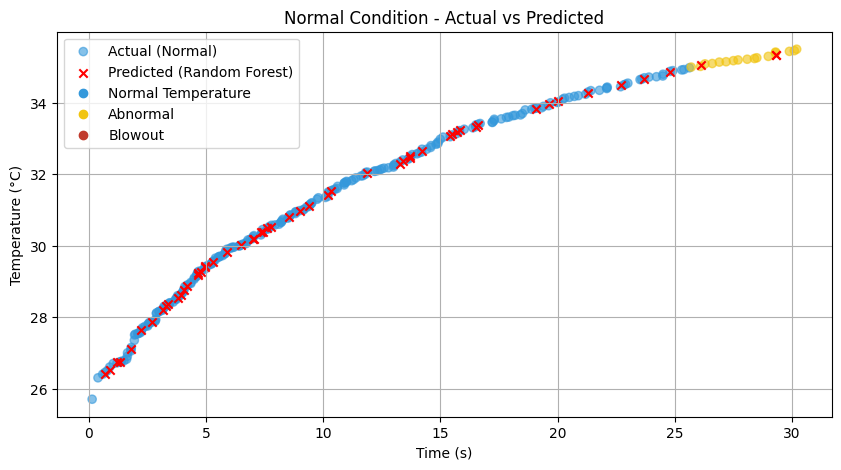

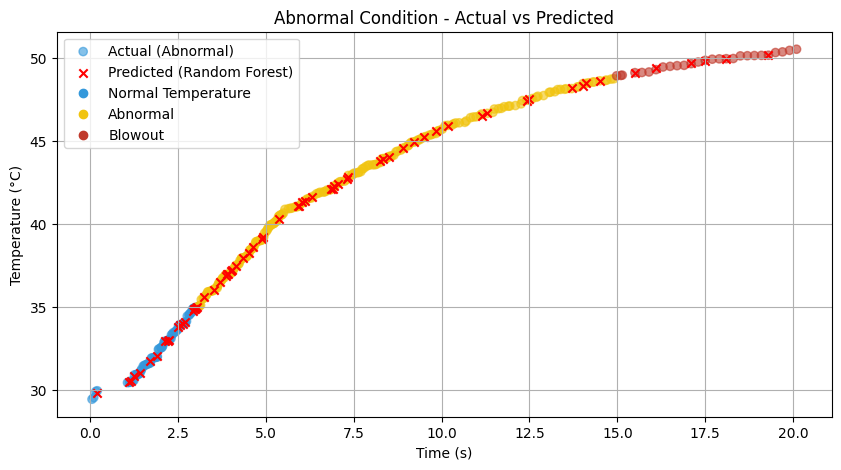

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import drive
import os
import joblib

# Mount Google Drive if not already mounted
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

# Mount Google Drive if not already mounted
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

# Define folder path where your dataset is stored
folder_path = "/content/drive/My Drive/dataset/"

# List all Excel files in the dataset folder
excel_files = [f for f in os.listdir(folder_path) if f.endswith(".xlsx")]

# Display available files
print("Available Excel files:")
for idx, file in enumerate(excel_files):
    print(f"{idx + 1}: {file}")

# Allow user to select a file
file_index = int(input("Select a file by number: ")) - 1
file_path = os.path.join(folder_path, excel_files[file_index])

print(f"You selected: {excel_files[file_index]}")


# Load dataset and check available sheets
xls = pd.ExcelFile(file_path)

# Load the first sheet, skipping incorrect row 0
df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0], skiprows=1)

# Rename columns properly
df.columns = ["Normal_Time", "Normal_Temperature", "Abnormal_Time", "Abnormal_Temperature"]

# Convert columns to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Impute missing values using the median
df.fillna({"Normal_Temperature": df["Normal_Temperature"].median(),
          "Abnormal_Temperature": df["Abnormal_Temperature"].median()}, inplace=True)

# Classification for Normal and Abnormal Conditions
def classify_condition(temp):
    if 25.5 <= temp < 35:
        return 'Normal'
    elif 35 <= temp < 48.9:
        return 'Abnormal'
    elif 48.9 <= temp <= 60:
        return 'Blowout'
    else:
        return 'Out of Range'

# Assign Colors for Different Conditions
def assign_color(condition):
    color_mapping = {
        "Normal": "#3498DB",      # Blue
        "Abnormal": "#F1C40F",    # Yellow
        "Blowout": "#C0392B",     # Dark Red
        "Out of Range": "#2C3E50"  # Black
    }
    return color_mapping.get(condition, "#8E44AD")  # Purple for unknown

# Apply classification and color mapping
df["Normal_Condition"] = df["Normal_Temperature"].apply(classify_condition)
df["Abnormal_Condition"] = df["Abnormal_Temperature"].apply(classify_condition)
df["Normal_Color"] = df["Normal_Condition"].apply(assign_color)
df["Abnormal_Color"] = df["Abnormal_Condition"].apply(assign_color)

# Plot Box Plot to Detect Outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=[df["Normal_Temperature"], df["Abnormal_Temperature"]])
plt.xticks([0, 1], ["Normal Temperature", "Abnormal Temperature"])
plt.title("Box Plot of Temperature Data")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

# Remove Outliers Using IQR Method
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df = remove_outliers(df, "Normal_Temperature")
df = remove_outliers(df, "Abnormal_Temperature")


# Train-Test Split for Normal and Abnormal Data
X_train_normal, X_test_normal, y_train_normal, y_test_normal = train_test_split(
    df[["Normal_Time"]], df["Normal_Temperature"], test_size=0.2, random_state=42)

X_train_abnormal, X_test_abnormal, y_train_abnormal, y_test_abnormal = train_test_split(
    df[["Abnormal_Time"]], df["Abnormal_Temperature"], test_size=0.2, random_state=42)

# Train Random Forest Models for Both Conditions
rf_normal = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_abnormal = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

rf_normal.fit(X_train_normal, y_train_normal)
rf_abnormal.fit(X_train_abnormal, y_train_abnormal)

# Predictions for Normal and Abnormal Conditions
y_pred_normal = rf_normal.predict(X_test_normal)
y_pred_abnormal = rf_abnormal.predict(X_test_abnormal)

# Evaluate Model Accuracy in Percentage
def calculate_accuracy(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    return r2 * 100

# Calculate accuracy for both conditions
normal_accuracy = calculate_accuracy(y_test_normal, y_pred_normal)
abnormal_accuracy = calculate_accuracy(y_test_abnormal, y_pred_abnormal)

# Combine accuracies based on sample sizes (weighted average)
n_normal = len(y_test_normal)
n_abnormal = len(y_test_abnormal)

accuracy = ((normal_accuracy * n_normal) + (abnormal_accuracy * n_abnormal)) / (n_normal + n_abnormal)

# Display the combined accuracy
print(f"Random Forest Accuracy: {accuracy:.2f}%")


# Create DataFrames for Predictions
normal_predictions_df = pd.DataFrame({
    "Normal_Time": X_test_normal["Normal_Time"].values,
    "Actual_Normal_Temperature": y_test_normal.values,
    "Predicted_Normal_Temperature": y_pred_normal
})

abnormal_predictions_df = pd.DataFrame({
    "Abnormal_Time": X_test_abnormal["Abnormal_Time"].values,
    "Actual_Abnormal_Temperature": y_test_abnormal.values,
    "Predicted_Abnormal_Temperature": y_pred_abnormal
})

# Merge both predictions for easier analysis
predictions_df = pd.concat([normal_predictions_df, abnormal_predictions_df], axis=1)

# Extract the original filename without extension
input_filename = os.path.splitext(excel_files[file_index])[0]

# Define output file path with dynamic naming
output_file_path = os.path.join(folder_path, f"Predicted({input_filename}).xlsx")

# Save predictions to Excel in the same directory
predictions_df.to_excel(output_file_path, index=False)

print(f"Predictions saved successfully at: {output_file_path}")


# Fault Detection Logic
threshold = 5
fault_indices = np.where(np.abs(df["Normal_Temperature"] - df["Abnormal_Temperature"]) > threshold)[0]

# Plot Fault Detection Graph
plt.figure(figsize=(12, 6))

plt.plot(df["Normal_Time"], df["Normal_Temperature"], label="Normal Condition", color='blue')
plt.plot(df["Abnormal_Time"], df["Abnormal_Temperature"], label="Abnormal Condition", color='brown')
plt.scatter(df.iloc[fault_indices]["Abnormal_Time"], df.iloc[fault_indices]["Abnormal_Temperature"],
            color='red', label="Detected Faults", marker='x')

if len(fault_indices) > 0:
    plt.axvline(df.iloc[fault_indices[0]]["Abnormal_Time"], color='red', linestyle='--', label="Fault Start")
    plt.axvline(df.iloc[fault_indices[-1]]["Abnormal_Time"], color='red', linestyle='--', label="Fault End")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Battery Temperature Fault Detection with Difference Analysis")
plt.legend()
plt.grid()
plt.show()


# Comparison of Normal and Abnormal Conditions (Updated with legend for all conditions)
plt.figure(figsize=(10, 5))

# Scatter plots for normal and abnormal conditions with specific colors
plt.scatter(df["Normal_Time"], df["Normal_Temperature"], c=df["Normal_Color"], label="Normal Condition", alpha=0.6)
plt.scatter(df["Abnormal_Time"], df["Abnormal_Temperature"], c=df["Abnormal_Color"], label="Abnormal Condition", alpha=0.6, marker='x')

# Add placeholder points to show the color legend
plt.scatter([], [], color="#3498DB", label="Normal Temperature")  # Blue for Normal
plt.scatter([], [], color="#F1C40F", label="Abnormal")            # Yellow for Abnormal
plt.scatter([], [], color="#C0392B", label="Blowout")             # Red for Blowout

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Comparison of Normal and Abnormal Conditions")
plt.legend()
plt.grid()
plt.show()

# Normal Condition Prediction Graph (Updated with legend for all conditions)
plt.figure(figsize=(10, 5))

# Scatter plot for actual normal conditions with specific colors
plt.scatter(df["Normal_Time"], df["Normal_Temperature"], c=df["Normal_Color"], label="Actual (Normal)", alpha=0.6)

# Predicted values from Random Forest
plt.scatter(X_test_normal, y_pred_normal, label="Predicted (Random Forest)", color="red", marker='x')

# Add placeholder points to show the color legend
plt.scatter([], [], color="#3498DB", label="Normal Temperature")  # Blue for Normal
plt.scatter([], [], color="#F1C40F", label="Abnormal")            # Yellow for Abnormal
plt.scatter([], [], color="#C0392B", label="Blowout")             # Red for Blowout

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Normal Condition - Actual vs Predicted")
plt.legend()
plt.grid()
plt.show()


# Abnormal Condition Prediction Graph (Updated with legend for all conditions)
plt.figure(figsize=(10, 5))

# Scatter plot for actual abnormal conditions with specific colors
plt.scatter(df["Abnormal_Time"], df["Abnormal_Temperature"], c=df["Abnormal_Color"], label="Actual (Abnormal)", alpha=0.6)

# Predicted values from Random Forest
plt.scatter(X_test_abnormal, y_pred_abnormal, label="Predicted (Random Forest)", color="red", marker='x')

# Add separate points to define color-based legend
plt.scatter([], [], color="#3498DB", label="Normal Temperature")  # Blue for Normal
plt.scatter([], [], color="#F1C40F", label="Abnormal")            # Yellow for Abnormal
plt.scatter([], [], color="#C0392B", label="Blowout")             # Red for Blowout

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Abnormal Condition - Actual vs Predicted")
plt.legend()
plt.grid()
plt.show()


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters for Normal Condition: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters for Abnormal Condition: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Performance After Hyperparameter Tuning for Normal Condition:
Training MAE: 0.0115, Test MAE: 0.0280
Training R²: 0.9999, Test R²: 0.9997


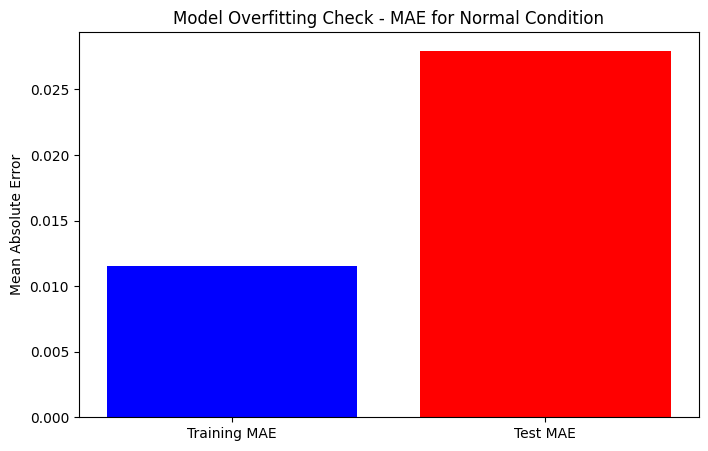

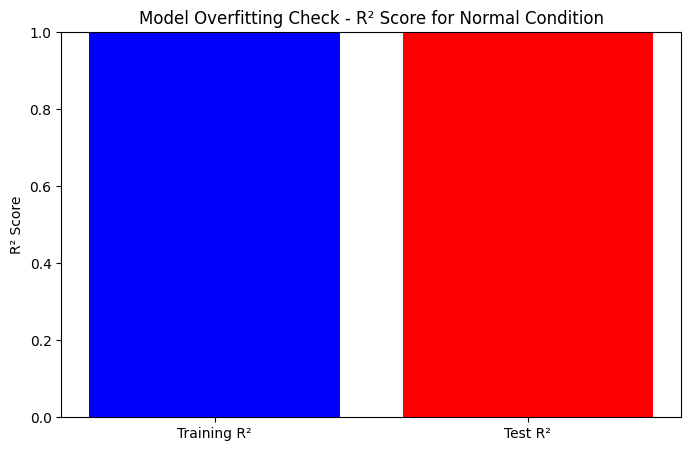


Performance After Hyperparameter Tuning for Abnormal Condition:
Training MAE: 0.0193, Test MAE: 0.0480
Training R²: 1.0000, Test R²: 0.9999


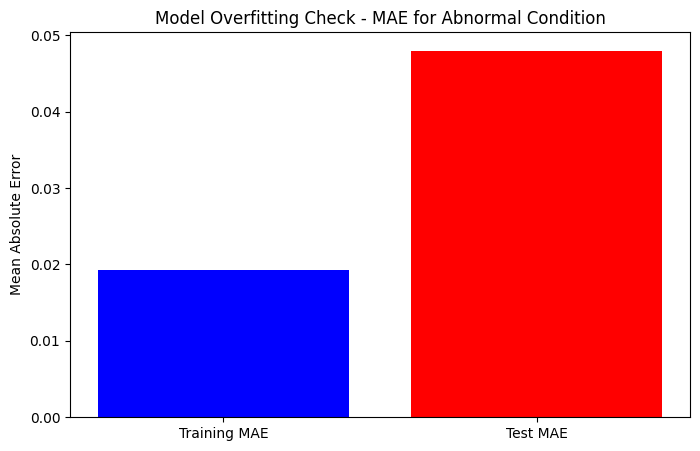

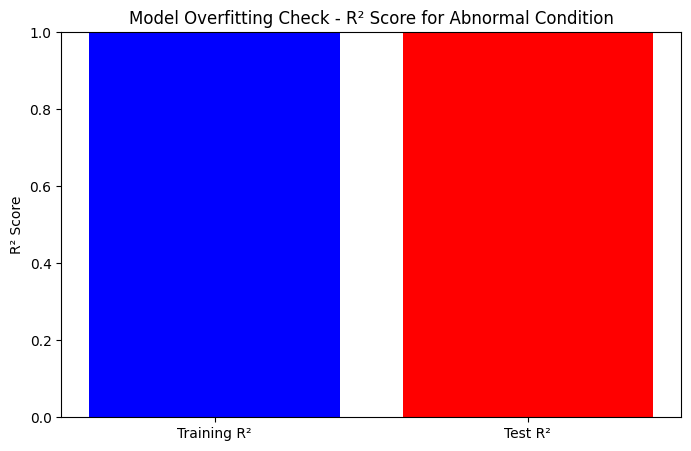

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Train-Test Split for Normal and Abnormal Data
X_train_normal, X_test_normal, y_train_normal, y_test_normal = train_test_split(
    df[["Normal_Time"]], df["Normal_Temperature"], test_size=0.2, random_state=42)

X_train_abnormal, X_test_abnormal, y_train_abnormal, y_test_abnormal = train_test_split(
    df[["Abnormal_Time"]], df["Abnormal_Temperature"], test_size=0.2, random_state=42)

# Define Hyperparameter Grid
param_grid = {
    "n_estimators": [50, 100, 200],     # Number of trees in the forest
    "max_depth": [3, 5, 10],            # Maximum depth of the trees
    "min_samples_split": [2, 5, 10],    # Minimum samples required to split a node
    "min_samples_leaf": [1, 3, 5],      # Minimum samples required at a leaf node
}

# Initialize Random Forest Model
rf = RandomForestRegressor(random_state=42)

# Grid Search with Cross-Validation for Normal Condition
grid_search_normal = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)
grid_search_normal.fit(X_train_normal, y_train_normal)

# Get Best Parameters and Model for Normal Condition
best_params_normal = grid_search_normal.best_params_
best_model_normal = grid_search_normal.best_estimator_
print(f"Best Hyperparameters for Normal Condition: {best_params_normal}")

# Grid Search with Cross-Validation for Abnormal Condition
grid_search_abnormal = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)
grid_search_abnormal.fit(X_train_abnormal, y_train_abnormal)

# Get Best Parameters and Model for Abnormal Condition
best_params_abnormal = grid_search_abnormal.best_params_
best_model_abnormal = grid_search_abnormal.best_estimator_
print(f"Best Hyperparameters for Abnormal Condition: {best_params_abnormal}")

# Evaluate Best Models

def evaluate_model(model, X_train, X_test, y_train, y_test, condition):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"\nPerformance After Hyperparameter Tuning for {condition}:")
    print(f"Training MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")
    print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")

    # Plot Performance
    plt.figure(figsize=(8, 5))
    plt.bar(["Training MAE", "Test MAE"], [train_mae, test_mae], color=["blue", "red"])
    plt.title(f"Model Overfitting Check - MAE for {condition}")
    plt.ylabel("Mean Absolute Error")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(["Training R²", "Test R²"], [train_r2, test_r2], color=["blue", "red"])
    plt.title(f"Model Overfitting Check - R² Score for {condition}")
    plt.ylabel("R² Score")
    plt.ylim(0, 1)
    plt.show()

# Evaluate both models
evaluate_model(best_model_normal, X_train_normal, X_test_normal, y_train_normal, y_test_normal, "Normal Condition")
evaluate_model(best_model_abnormal, X_train_abnormal, X_test_abnormal, y_train_abnormal, y_test_abnormal, "Abnormal Condition")


 Model Performance After Hyperparameter Tuning:
Training MAE: 0.2900, Test MAE: 0.4354
Training R²: 0.9895, Test R²: 0.9732
Training Accuracy: 99.20%, Test Accuracy: 98.66%


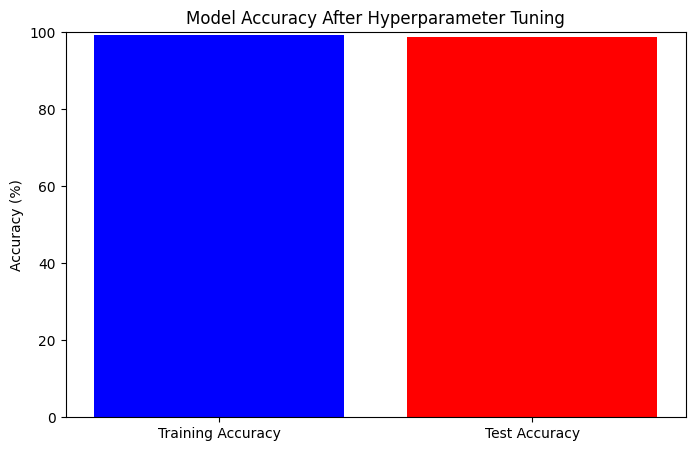

In [ ]:
# Predictions using the best model from GridSearchCV
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Evaluation Metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Mean Absolute Percentage Error (MAPE) & Accuracy Calculation
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

train_accuracy = 100 - train_mape
test_accuracy = 100 - test_mape

# Display Performance Metrics
print("\n Model Performance After Hyperparameter Tuning:")
print(f"Training MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")
print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"Training Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

# Plot Accuracy Comparison
plt.figure(figsize=(8, 5))
plt.bar(["Training Accuracy", "Test Accuracy"], [train_accuracy, test_accuracy], color=["blue", "red"])
plt.title("Model Accuracy After Hyperparameter Tuning")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()


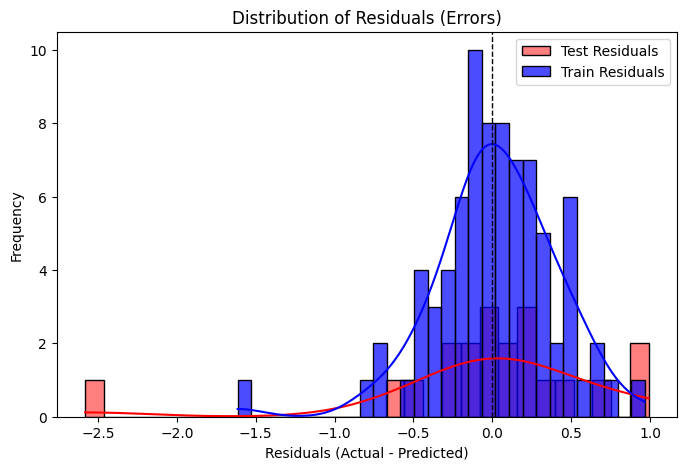

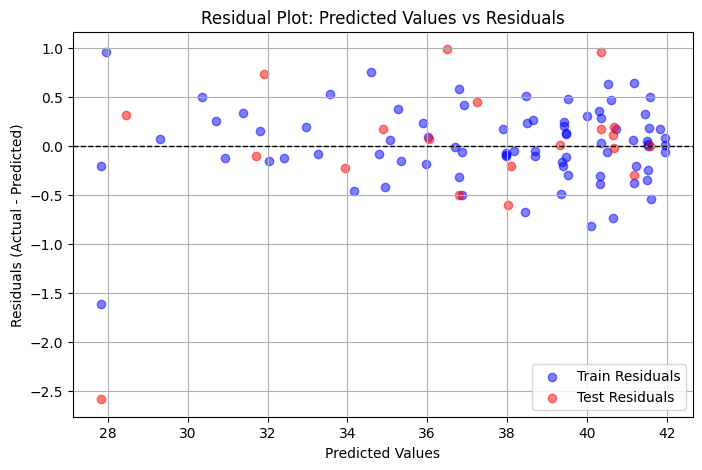

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate Residuals (Errors)
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Histogram of Errors (Residuals)
plt.figure(figsize=(8, 5))
sns.histplot(test_residuals, bins=30, kde=True, color="red", label="Test Residuals")
sns.histplot(train_residuals, bins=30, kde=True, color="blue", label="Train Residuals", alpha=0.7)
plt.axvline(0, color='black', linestyle='dashed', linewidth=1)
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Residual Plot (Predicted vs Residuals)
plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, train_residuals, color="blue", alpha=0.5, label="Train Residuals")
plt.scatter(y_test_pred, test_residuals, color="red", alpha=0.5, label="Test Residuals")
plt.axhline(0, color='black', linestyle='dashed', linewidth=1)
plt.title("Residual Plot: Predicted Values vs Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid()
plt.show()

